# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

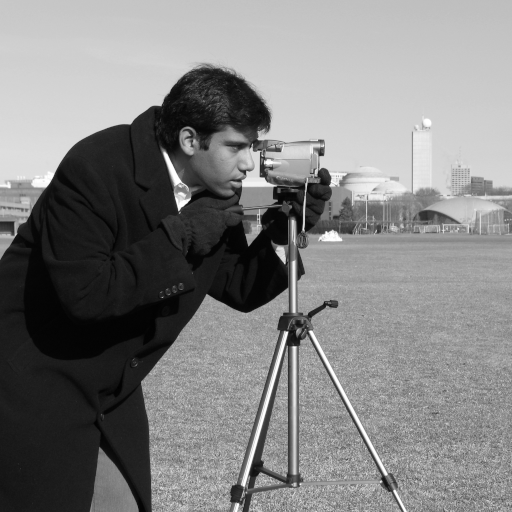

In [2]:
# ── Load image ────────────────────────────────────
from skimage import data

original_image = data.camera()
img = Image.fromarray(original_image)
img


### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image
width, height = img.size
print(width, height)

# scaling factors
scale_x = 2
scale_y = 2


512 512


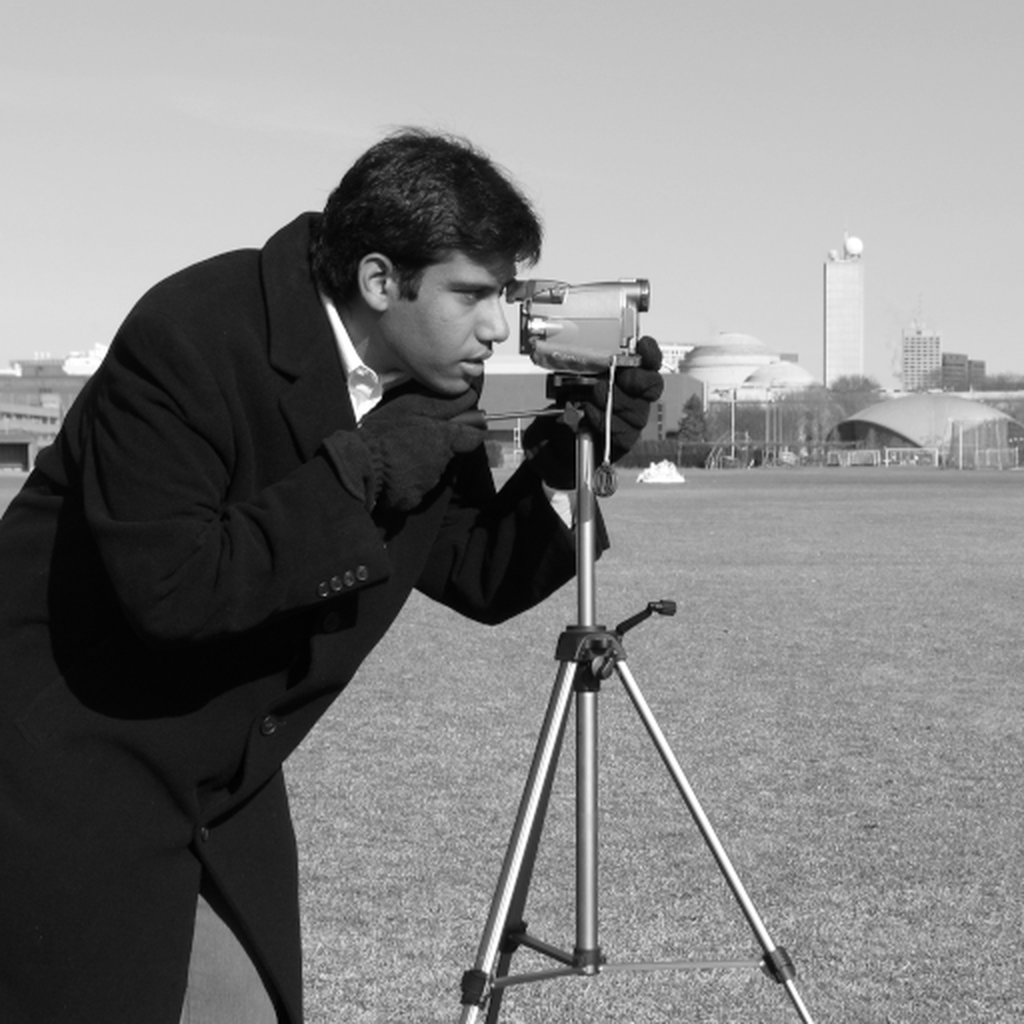

In [4]:
# ── 1. Increase size (scale ×2) ────────────────────
new_width = width * scale_x
new_height = height * scale_y

# Resize the image using PIL's built-in method
scaled_img = img.resize((new_width, new_height), Image.LANCZOS)
scaled_img

In [5]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save('task1_1_scaled.jpg')

print('Original size:', img.size)
print('Scaled size:', scaled_img.size)

Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [6]:
width, height = img.size

cx = 2
cy = 1


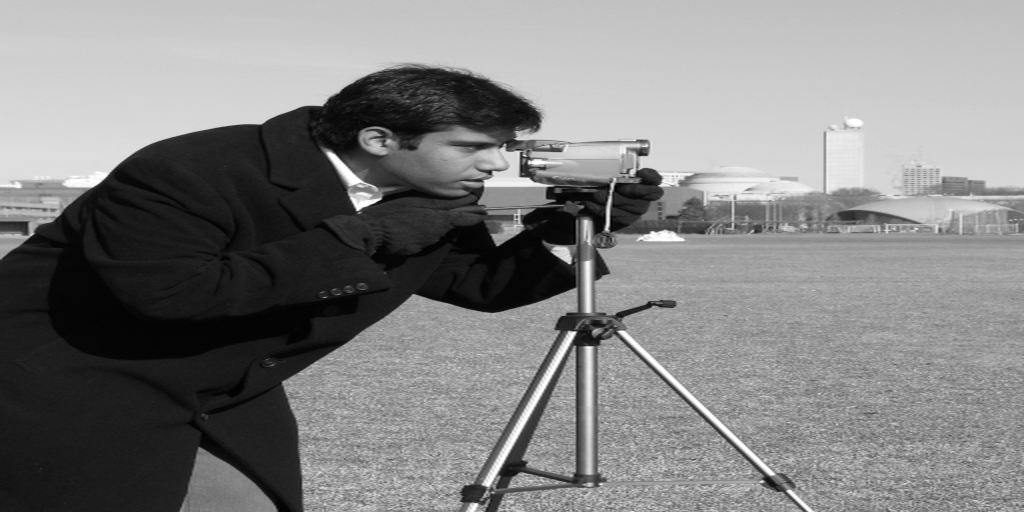

In [7]:
new_width = int(width * cx)
new_height = int(height * cy)

nonuniform_img = img.resize((new_width, new_height), Image.LANCZOS)
nonuniform_img

In [8]:
nonuniform_img.save('task1_1b_nonuniform_scaled.jpg')

print('Original size:', img.size)
print('Non-uniform scaled size:', nonuniform_img.size)

Original size: (512, 512)
Non-uniform scaled size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size: (700, 700)


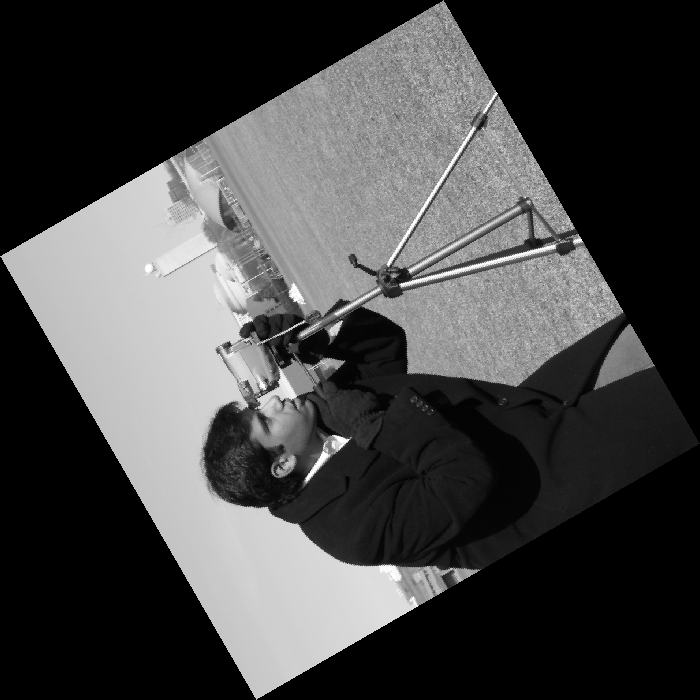

In [9]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img.rotate(120, expand=True)
rotated_img.save('task1_2_rotated.jpg')

print('Original size:', img.size)
print('Rotated size:', rotated_img.size)
rotated_img


### 3. Shear

In [10]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size

In [11]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5

shx = shear_factor
shy = 0
tx = 0
ty = 0


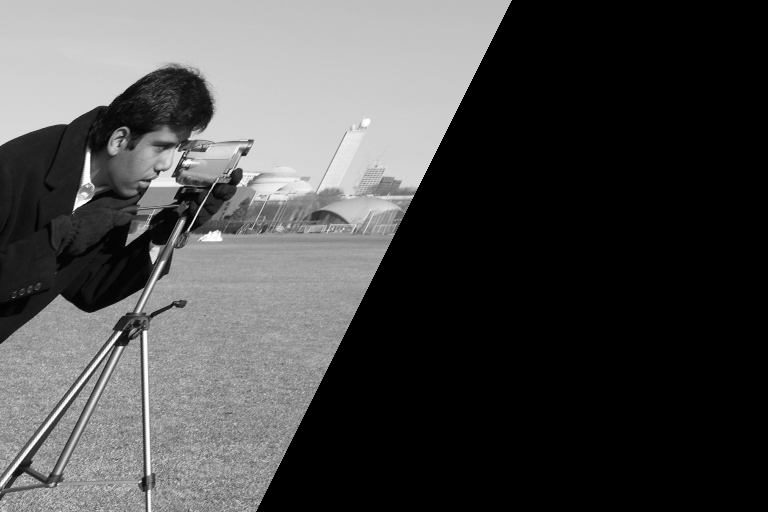

In [12]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
new_width = int(width + shear_factor * height)
new_height = height

sheared_img = img.transform((new_width, new_height), Image.AFFINE, (1, shx, tx, shy, 1, ty), resample=Image.BICUBIC)
sheared_img



In [13]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
sheared_img.save('task1_3_sheared.jpg')

print('Original size:', img.size)
print('Sheared size:', sheared_img.size)



Original size: (512, 512)
Sheared size: (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

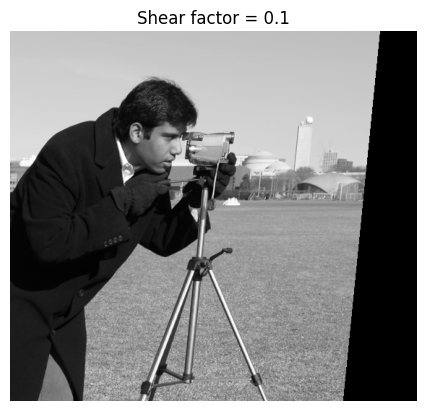

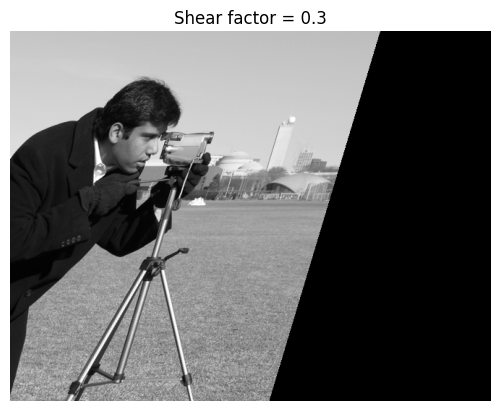

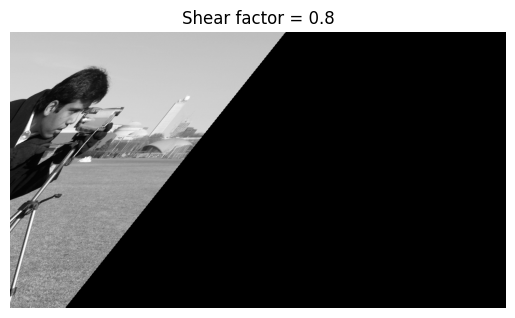

In [14]:
# 1) Try different shear factors
for shear_factor in [0.1, 0.3, 0.8]:
    shx = shear_factor
    shy = 0
    tx = 0
    ty = 0

    new_width = int(width + shear_factor * height)
    new_height = height

    sheared_img = img.transform((new_width, new_height), Image.AFFINE, (1, shx, tx, shy, 1, ty), resample=Image.BICUBIC)

    plt.imshow(sheared_img, cmap='gray')
    plt.title('Shear factor = ' + str(shear_factor))
    plt.axis('off')
    plt.show()


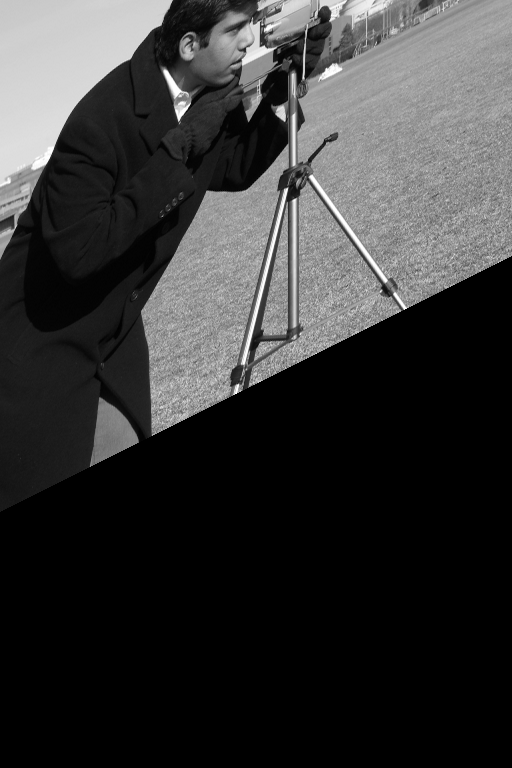

In [15]:
# 2) Switch from X-axis to Y-axis shear
shear_factor = 0.5

shx = 0              # no shear on X
shy = shear_factor   # shear on Y instead
tx = 0
ty = 0

new_width = width
new_height = int(height + shear_factor * width)   # canvas grows in height now

sheared_img_y = img.transform((new_width, new_height), Image.AFFINE, (1, shx, tx, shy, 1, ty), resample=Image.BICUBIC)
sheared_img_y


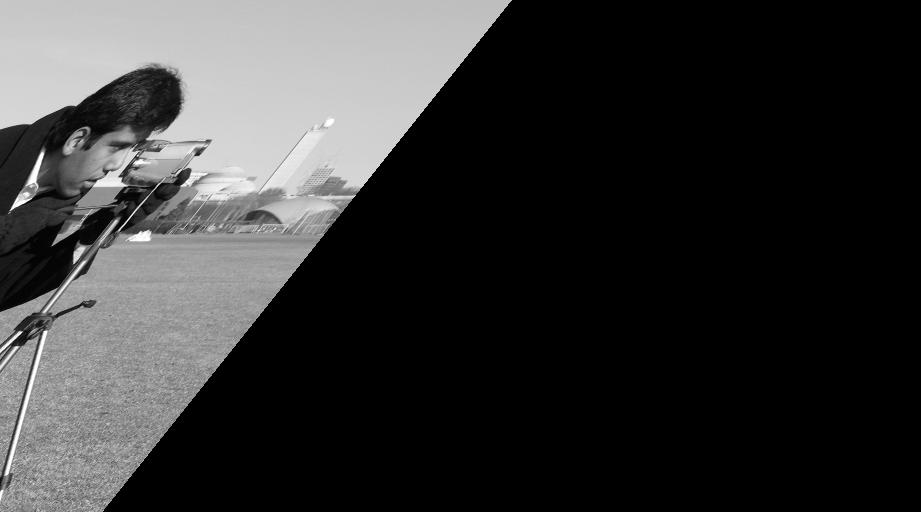

In [16]:
# 3) Update the canvas multiplier to match the new factor
shear_factor = 0.8

shx = shear_factor
shy = 0
tx = 0
ty = 0

new_width = int(width + shear_factor * height)   # canvas width updated to match shear_factor
new_height = height

sheared_img_updated = img.transform((new_width, new_height), Image.AFFINE, (1, shx, tx, shy, 1, ty), resample=Image.BICUBIC)
sheared_img_updated


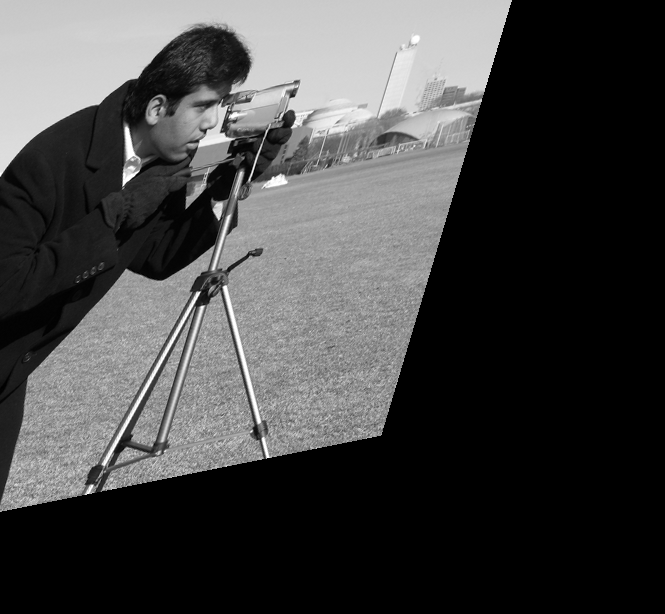

In [17]:
# 4) Combine X and Y shear in one matrix
shx = 0.3   # horizontal shear
shy = 0.2   # vertical shear
tx = 0
ty = 0

new_width = int(width + shx * height)
new_height = int(height + shy * width)

sheared_img_xy = img.transform((new_width, new_height), Image.AFFINE, (1, shx, tx, shy, 1, ty), resample=Image.BICUBIC)
sheared_img_xy


# Intensity Transformations
Negative · Log · Power Law (Gamma)

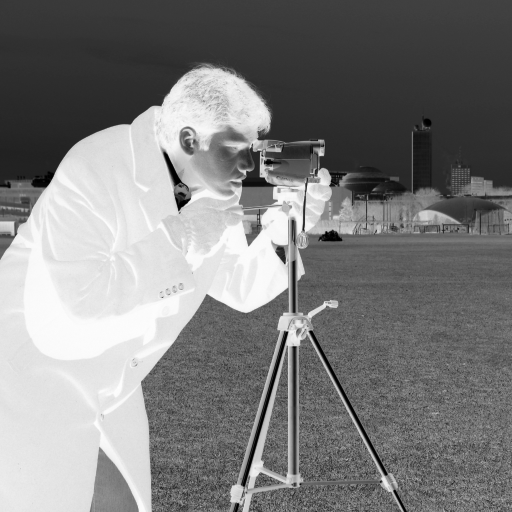

In [18]:

# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation
arr = np.array(img)

negative_arr = 255 - arr

negative_img = Image.fromarray(negative_arr)
negative_img



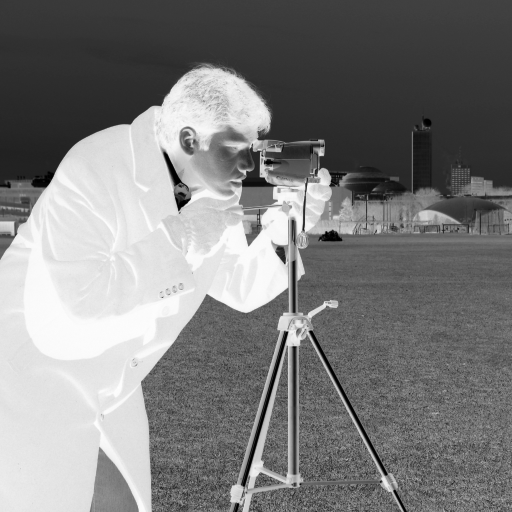

In [19]:
# Method 2: PIL's ImageOps
negative_img2 = ImageOps.invert(img)
negative_img2


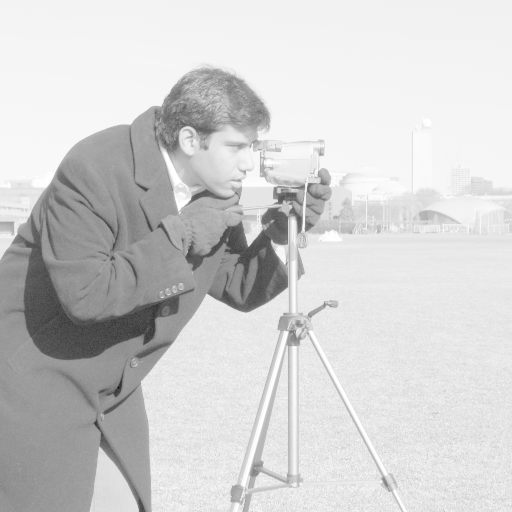

In [20]:
# ── 2. Log transformation ──────────────────────────
arr = np.array(img, dtype=np.float64)

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
log_transformed_arr = c * np.log(1 + arr)
log_transformed_img = Image.fromarray(np.uint8(log_transformed_arr))
log_transformed_img

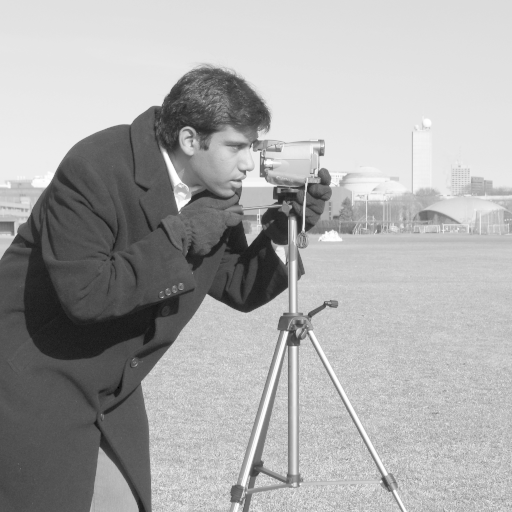

In [21]:

# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5

arr = np.array(img, dtype=np.float64) / 255.0
gamma_corrected_arr = np.power(arr, gamma) * 255.0

gamma_img = Image.fromarray(np.uint8(gamma_corrected_arr))
gamma_img



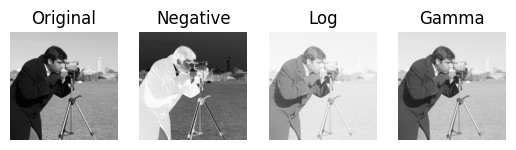

In [22]:
plt.subplot(1, 4, 1), plt.imshow(img, cmap='gray'), plt.title('Original'), plt.axis('off')
plt.subplot(1, 4, 2), plt.imshow(negative_img, cmap='gray'), plt.title('Negative'), plt.axis('off')
plt.subplot(1, 4, 3), plt.imshow(log_transformed_img, cmap='gray'), plt.title('Log'), plt.axis('off')
plt.subplot(1, 4, 4), plt.imshow(gamma_img, cmap='gray'), plt.title('Gamma'), plt.axis('off')
plt.show()
